In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [2]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [3]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


# Using t = 0 DBD threshold
Don't subtract baseline. just compare to DBDs at t = 0

In [4]:
DBD_tiles = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/measured_DBDs.csv", index_col = 0)
DBD_tiles

,AD_protein
1500,EEEQELAKLCAEKEGQWAEIGKTLGRMPEDCRDRWRNYVK
1917,GKWTAEEEQELAKLCAEKEGQWAEIGKTLGRMPEDCRDRW
5186,RKSLMGNGKLDFKDIINWTIVSERMGGTRSRIQCRYKWNK
7390,FIQFTQEIRPTVVKENPDKGLIEITKIIGERWRELDPAKK
8134,LIEITKIIGERWRELDPAKKAEYTETYKKRLKEWESCYPD
...,...
450249,WLPINNVARLMKNTLPPSAKVSKDAKECMQECVSELISFV
450256,DVTFGQVGRILGERWKALTAEEKQPYESKAQADKKRYESE
450297,FFANENRDIVRSENPDVTFGQVGRILGERWKALTAEEKQP
450398,LSAYMFFANENRDIVRSENPDVTFGQVGRILGERWKALTA


In [5]:
DBD_activities = activities[activities["ADseq"].isin(DBD_tiles["AD_protein"])]
DBD_activities_t0 = DBD_activities[DBD_activities["time"] == 0]
DBD_activities_t0

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
6053,AYPDLLPLGLLNFLLDEFNMEVEKGDSFPYYETLSLEEFK,0,-0.247690,-0.453597,-0.076934,ns,NaN,NaN,0.096087,0.0,-0.205907,0.170755
11105,DLDRNDHTIMNDAMLSLEDNVMAALEMVQKEQQQKINHRG,0,0.107388,-0.189600,0.461644,ns,NaN,NaN,0.166134,0.0,-0.296989,0.354256
19031,ENSNLFYDIFEEIIDSLPSVSDSGSLTPKNLYVSNNSSGL,0,0.450177,0.088346,0.704110,ns,NaN,NaN,0.157083,0.0,-0.361831,0.253933
20702,ETIATMYPIPAYPDLLPLGLLNFLLDEFNMEVEKGDSFPY,0,0.099674,-0.216133,0.352081,ns,NaN,NaN,0.144952,0.0,-0.315807,0.252407
22137,FDQILESSYNNSNHTVSKFKVSHYVEESGLLDILMQRYGL,0,-0.159260,-0.482525,0.049975,ns,NaN,NaN,0.135842,0.0,-0.323266,0.209235
30065,GTNRFSETVLPPQMAAEQSWSDSNMELEICLDYLHNELEV,0,-0.051056,-0.354991,0.275337,ns,NaN,NaN,0.160798,0.0,-0.303935,0.326393
38095,IQNKIKDSLTLSSKEKELLHLIEHGAEQTTENSNLFYDIF,0,0.051553,-0.183231,0.366702,ns,NaN,NaN,0.140289,0.0,-0.234784,0.315149
40984,KDSLTLSSKEKELLHLIEHGAEQTTENSNLFYDIFEEIID,0,0.074518,-0.060725,0.247544,ns,NaN,NaN,0.078640,0.0,-0.135243,0.173026
41269,KELLHLIEHGAEQTTENSNLFYDIFEEIIDSLPSVSDSGS,0,0.132480,-0.148587,0.465780,ns,NaN,NaN,0.156726,0.0,-0.281066,0.333300
49450,LDSADDPILVQFAKMNHVLENIHTHLHERDLNDDEFDDPI,0,-0.102619,-0.295476,0.071022,ns,NaN,NaN,0.093495,0.0,-0.192857,0.173641


In [6]:
threshold = np.percentile(DBD_activities_t0["activity"], 99)

In [7]:
import numpy as np
import pandas as pd


def summarize_adseq(g):
    g = g.sort_values("time")

    # max activity over time
    max_activity = g["activity"].max()

    # first passage time (threshold crossing)
    hit = g[g["activity"] >= threshold]

    if len(hit) == 0:
        first_pass_time = np.nan
    else:
        first_pass_time = hit["time"].iloc[0]

    return pd.Series({
        "max_activity": max_activity,
        "first_pass_time": first_pass_time
    })


summary_df = activities.groupby("ADseq").apply(summarize_adseq).reset_index()
summary_df

,ADseq,max_activity,first_pass_time
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.801983,15.0
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.970491,2.0
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.285137,10.0
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.191691,10.0
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.624554,10.0
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.376673,10.0
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.136863,15.0
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.463755,10.0
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.288224,10.0


In [8]:
summary_df = summary_df.dropna()
summary_df

,ADseq,max_activity,first_pass_time
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.801983,15.0
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.970491,2.0
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.285137,10.0
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.191691,10.0
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.624554,10.0
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.376673,10.0
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.136863,15.0
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.463755,10.0
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.288224,10.0


In [9]:
summary_df["first_pass_time"] = summary_df["first_pass_time"].astype(int)
summary_df

/tmp/ipykernel_2247965/3781769358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_df["first_pass_time"] = summary_df["first_pass_time"].astype(int)


,ADseq,max_activity,first_pass_time
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.801983,15
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,1.970491,2
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,1.285137,10
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,1.191691,10
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,1.624554,10
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,1.376673,10
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,1.136863,15
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,1.463755,10
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,1.288224,10


In [10]:
summary_df.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/first_passage_DBD.csv")

/tmp/ipykernel_2247965/4164796159.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


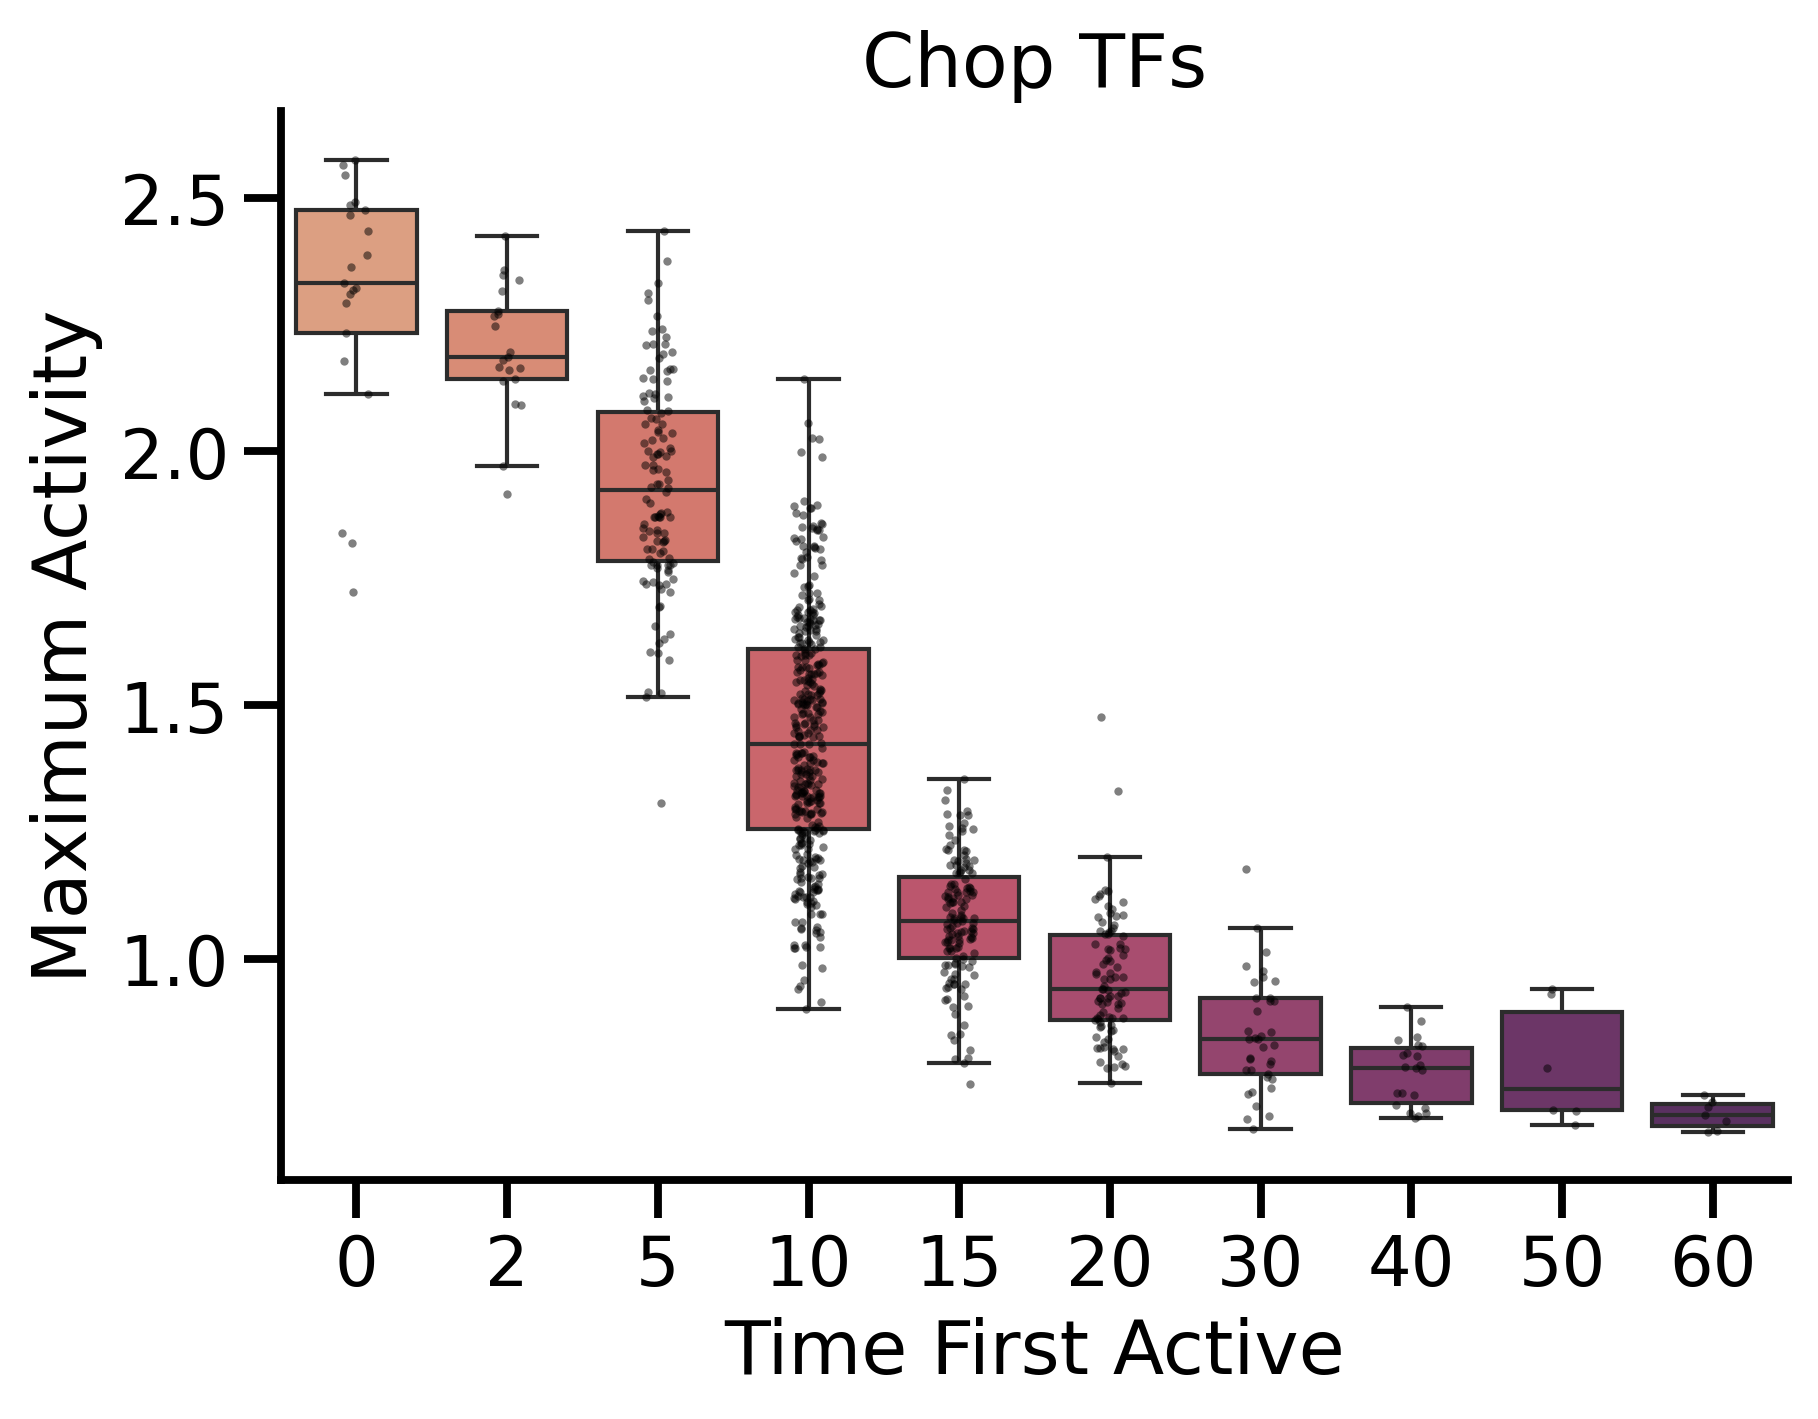

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk")

fig, ax = plt.subplots(dpi=300)

# --- boxplot FIRST (background) ---
sns.boxplot(
    data=summary_df,
    x="first_pass_time",
    y="max_activity",
    ax=ax,
    fliersize=0,
    linewidth=1,
    palette = 'flare'
)

# --- stripplot ON TOP ---
sns.stripplot(
    data=summary_df,
    x="first_pass_time",
    y="max_activity",
    ax=ax,
    alpha=0.5,
    size=2,
    color = 'black'
)

plt.ylabel("Maximum Activity")
plt.xlabel("Time First Active")

sns.despine()
plt.tight_layout()
plt.title("Chop TFs")
plt.show()


# Using bootstrap p-val threshold
Subtract basesline activities. Use class called from bootstrap comparison to t = 0. 

In [12]:
activities

,ADseq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,activity_norm,ci_low_norm,ci_hi_norm
142,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0,-0.402631,-0.569555,-0.165864,ns,NaN,NaN,0.102982,0.000000,-0.166925,0.236767
143,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,2,0.067719,-0.086268,0.196101,ns,0.470349,0.009113,0.072033,0.470349,0.316362,0.598732
144,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,0.423909,0.019486,0.796737,activator,0.826539,0.001168,0.198278,0.826539,0.422117,1.199367
145,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,15,0.786642,0.691610,0.871152,activator,1.189273,0.000881,0.045801,1.189273,1.094241,1.273783
146,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,20,0.567249,0.388742,0.736468,activator,0.969880,0.000730,0.088706,0.969880,0.791373,1.139099
...,...,...,...,...,...,...,...,...,...,...,...,...
118600,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,20,1.560700,1.399946,1.635293,activator,1.430020,0.000730,0.060037,1.430020,1.269266,1.504612
118601,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,30,1.707046,1.668821,1.736109,activator,1.576366,0.000621,0.017165,1.576366,1.538140,1.605428
118602,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,40,1.721909,1.702173,1.740391,activator,1.591228,0.000550,0.009749,1.591228,1.571493,1.609710
118603,YVPTRNTFNYDVKISNDFFDNGDNLYGNDEEVLFYEDNYN,50,1.650853,1.592250,1.699947,activator,1.520173,0.000548,0.027474,1.520173,1.461570,1.569266


In [13]:
import pandas as pd

def summarize_adseq_activity(df, use_norm=True):
    y = "activity_norm" if use_norm else "activity"

    results = []

    for ad, grp in df.sort_values("time").groupby("ADseq"):
        grp = grp.sort_values("time")

        # --- 1. first time labeled as activator ---
        activator_grp = grp[grp["class"] == "activator"]

        if len(activator_grp) > 0:
            first_active_time = activator_grp.iloc[0]["time"]
        else:
            first_active_time = None  # never active

        # --- 2. max activity (across all timepoints) ---
        max_idx = grp[y].idxmax()
        max_row = grp.loc[max_idx]

        results.append({
            "ADseq": ad,
            "first_pass_time": first_active_time,
            "max_activity": max_row[y],
        })

    return pd.DataFrame(results)

In [14]:
first_time_vs_active = summarize_adseq_activity(activities)
first_time_vs_active

,ADseq,first_pass_time,max_activity
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,10,1.204614
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,10,1.550627
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,10,1.411124
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,20,1.014475
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,10,1.486441
...,...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,10,1.453678
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,20,0.996907
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,10,1.520583
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,15,1.192689


/tmp/ipykernel_2247965/2228706347.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


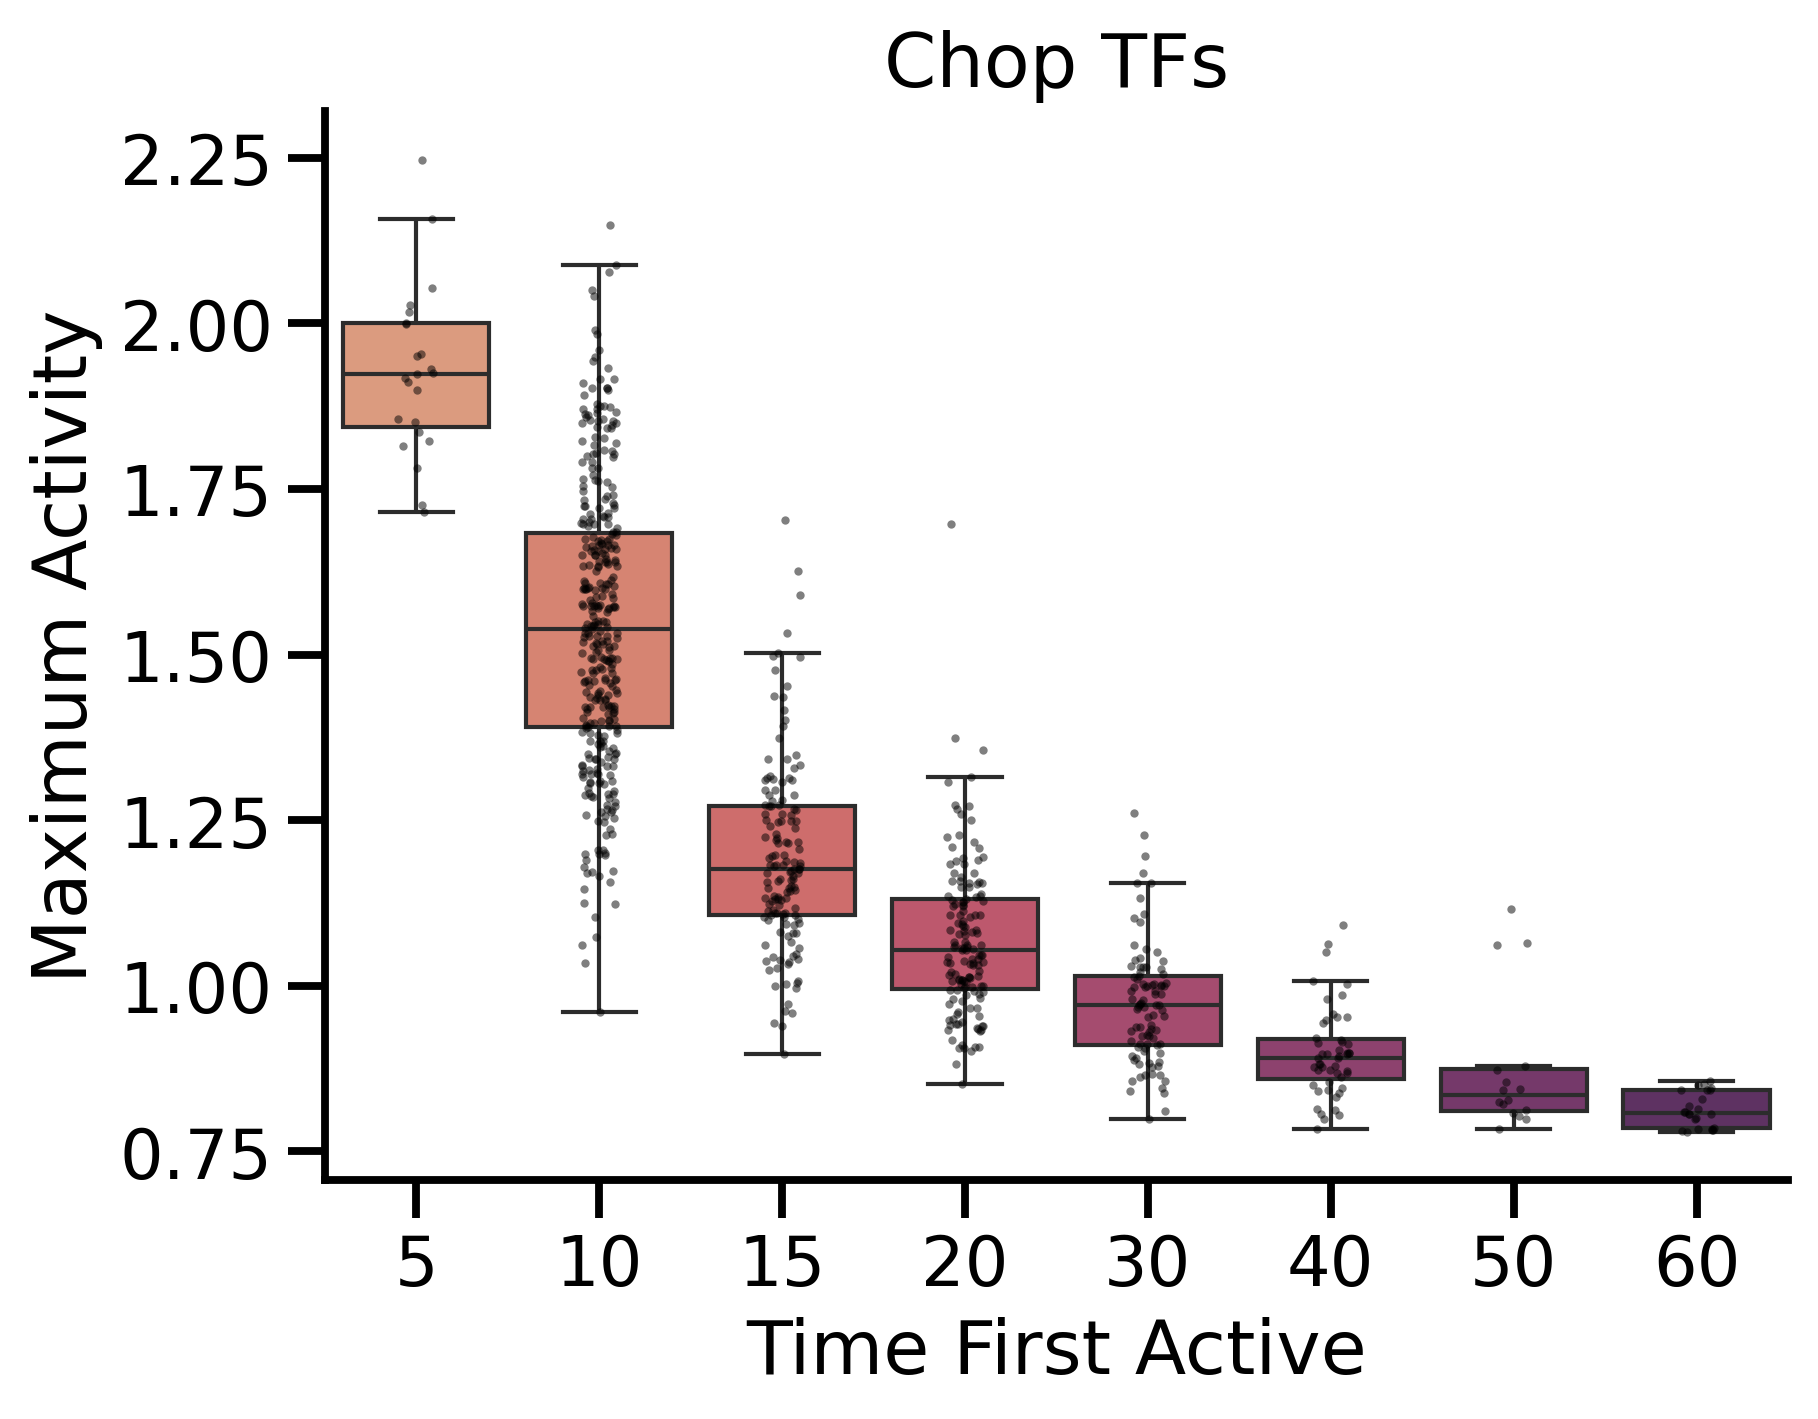

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk")

fig, ax = plt.subplots(dpi=300)

# --- boxplot FIRST (background) ---
sns.boxplot(
    data=first_time_vs_active,
    x="first_pass_time",
    y="max_activity",
    ax=ax,
    fliersize=0,
    linewidth=1,
    palette = 'flare'
)

# --- stripplot ON TOP ---
sns.stripplot(
    data=first_time_vs_active,
    x="first_pass_time",
    y="max_activity",
    ax=ax,
    alpha=0.5,
    size=2,
    color = 'black'
)

plt.ylabel("Maximum Activity")
plt.xlabel("Time First Active")

sns.despine()
plt.tight_layout()
plt.title("Chop TFs")
plt.show()


In [16]:
first_time_vs_active.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/ChopTFs_pipeline/speed/first_passage_pval_class.csv")